In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example for Sign Language MNIST
train = pd.read_csv("sign_mnist_train.csv")
test = pd.read_csv("sign_mnist_test.csv")

print(train.shape, test.shape)
train.head()


(1380, 785) (1379, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207.0,207.0,207.0,207.0,206.0,206.0,206.0,204.0,203.0,202.0
1,6,155,157,156,156,156,157,156,158,158,...,69.0,149.0,128.0,87.0,94.0,163.0,175.0,103.0,135.0,149.0
2,2,187,188,188,187,187,186,187,188,187,...,202.0,201.0,200.0,199.0,198.0,199.0,198.0,195.0,194.0,195.0
3,2,211,211,212,212,211,210,211,210,210,...,235.0,234.0,233.0,231.0,230.0,226.0,225.0,222.0,229.0,163.0
4,13,164,167,170,172,176,179,180,184,185,...,92.0,105.0,105.0,108.0,133.0,163.0,157.0,163.0,164.0,179.0


In [4]:
train.isnull().sum().any()


np.True_

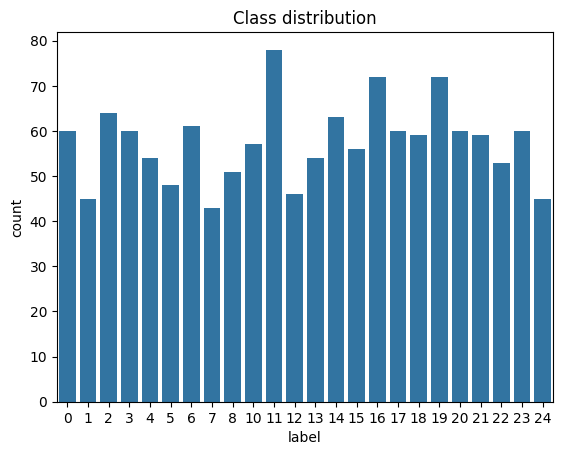

In [5]:
sns.countplot(x='label', data=train)
plt.title("Class distribution")
plt.show()


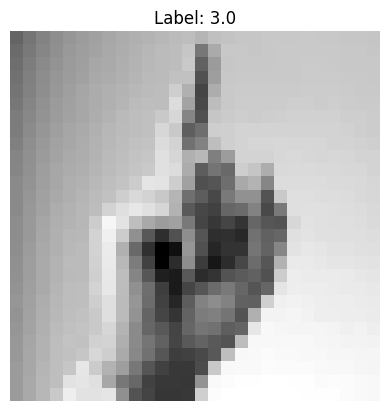

In [6]:
import numpy as np

def show_image(row):
    pixels = row.drop('label').values.reshape(28,28)
    plt.imshow(pixels, cmap='gray')
    plt.title(f"Label: {row['label']}")
    plt.axis('off')
    plt.show()

show_image(train.iloc[0])


In [7]:
print("Mean:", train.drop('label', axis=1).values.mean())
print("Std:", train.drop('label', axis=1).values.std())


Mean: nan
Std: nan


<Axes: >

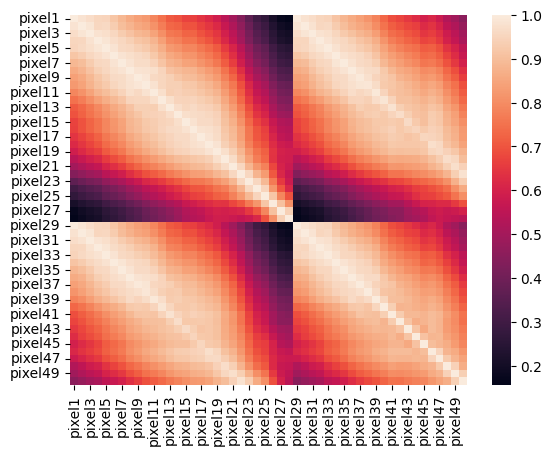

In [8]:
sns.heatmap(train.drop('label', axis=1).corr().iloc[:50,:50])


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Load dataset
train = pd.read_csv("sign_mnist_train.csv")
test = pd.read_csv("sign_mnist_test.csv")

# Split X and y
X_train = train.drop('label', axis=1).values
y_train = train['label'].values
X_test = test.drop('label', axis=1).values
y_test = test['label'].values

# Normalize pixel values (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN (28x28 images with 1 channel)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


In [10]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(y_train.shape[1], activation='softmax')   # output layer
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,969 (886.60 KB)

 Trainable params: 226,969 (886.60 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_data=(X_test, y_test))


Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.0455 - loss: nan - val_accuracy: 0.0451 - val_loss: nan
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.0405 - loss: nan - val_accuracy: 0.0451 - val_loss: nan
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.0438 - loss: nan - val_accuracy: 0.0451 - val_loss: nan
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.0421 - loss: nan - val_accuracy: 0.0451 - val_loss: nan
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.0501 - loss: nan - val_accuracy: 0.0451 - val_loss: nan
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.0451 - loss: nan - val_accuracy: 0.0451 - val_loss: nan
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.0405 - loss: nan - val_accuracy: 0.0451 - val_loss: nan
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.0464 - loss: nan - val_accuracy: 0.0451 - val_loss: nan
Epoch 9/10
49/49 ━━━━━━━━━━━━━━━

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")


98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0435 - loss: nan
Test Accuracy: 4.51%


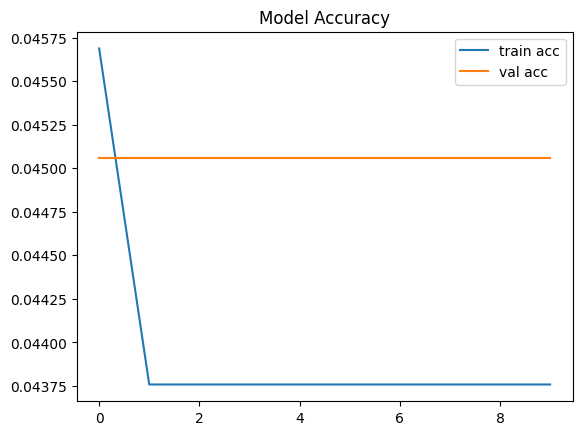

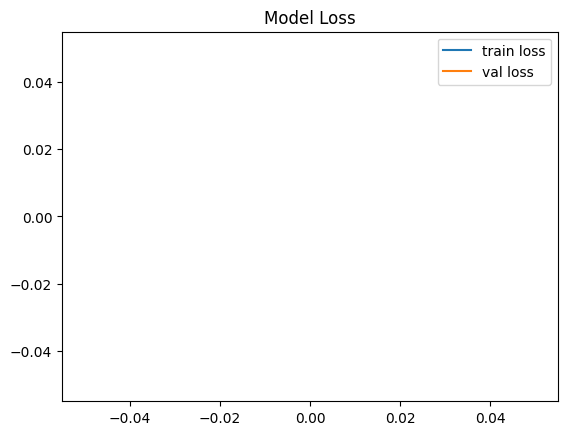

In [ ]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Model Loss")
plt.show()


Train shape: (27455, 785)
Test shape: (7172, 785)
Number of classes: 25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,969 (886.60 KB)

 Trainable params: 226,969 (886.60 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.2333 - loss: 2.5389 - val_accuracy: 0.7692 - val_loss: 0.7408
Epoch 2/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.7714 - loss: 0.6881 - val_accuracy: 0.8702 - val_loss: 0.3895
Epoch 3/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - accuracy: 0.8859 - loss: 0.3416 - val_accuracy: 0.8904 - val_loss: 0.3015
Epoch 4/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - accuracy: 0.9358 - loss: 0.1979 - val_accuracy: 0.9016 - val_loss: 0.2839
Epoch 5/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.9519 - loss: 0.1473 - val_accuracy: 0.9204 - val_loss: 0.2555
Epoch 6/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.9576 - loss: 0.1221 - val_accuracy: 0.9339 - val_loss: 0.2666
Epoch 7/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.9705 - loss: 0.0892 - val_accuracy: 0.9289 - val_loss: 0.2567
Epoch 8/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.9738 - loss: 0.0772 - 

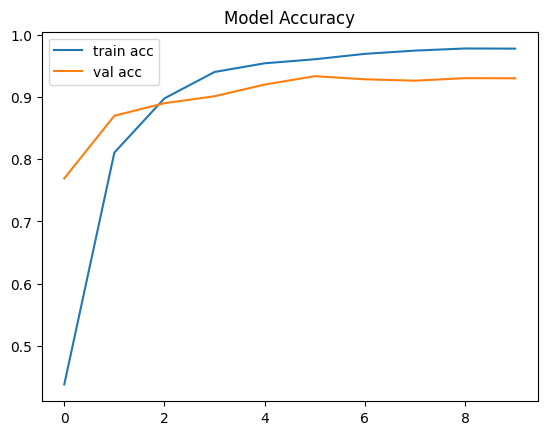

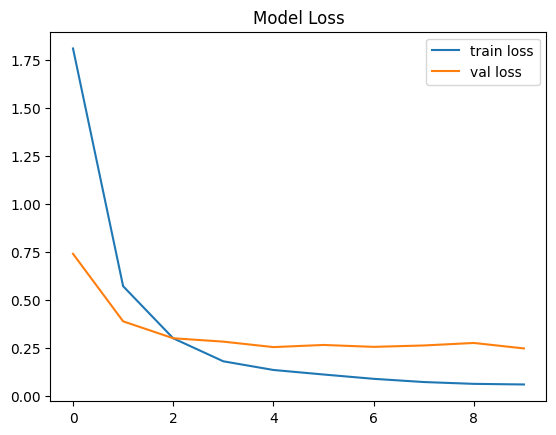

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


train = pd.read_csv("sign_mnist_train.csv")
test = pd.read_csv("sign_mnist_test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)


X_train = train.drop('label', axis=1).values
y_train = train['label'].values
X_test = test.drop('label', axis=1).values
y_test = test['label'].values


X_train = X_train / 255.0
X_test = X_test / 255.0


X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


num_classes = y_train.max() + 1
print("Number of classes:", num_classes)


y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)



model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')   # Output layer
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_data=(X_test, y_test))


loss, acc = model.evaluate(X_test, y_test)
print(f"✅ Test Accuracy: {acc*100:.2f}%")


plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Model Loss")
plt.show()


In [11]:
model.save("sign_lang_model.h5")
